# Stereo Project - Training Notebook

Run training only.

Edit the configuration cell below, then run all cells.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys, subprocess, re, datetime
from pathlib import Path


PROJECT_DIR = Path("/content/drive/MyDrive/stereo_project")
DATA_ROOT   = "/content/drive/MyDrive/kitti_data"
PSMNET_DIR  = "/content/PSMNet"

EPOCHS      = 50
BATCH_SIZE  = 1
LR          = 1e-4

DEGRADE_TYPE       = "blur"   # blur | noise | occlusion | random
DEGRADE_SEVERITY   = 4        # 1,2,3,4 or random
DEGRADE_CAMERA     = "left"   # left | right | random
TRAIN_DEGRADE_PROB = 0.7
EVAL_DEGRADE_PROB  = 1.0
GATE_LOSS_WEIGHT   = 0.10


if not Path(PSMNET_DIR).exists():
    !git clone https://github.com/JiaRenChang/PSMNet.git
!pip -q install torch torchvision torchaudio numpy opencv-python pillow matplotlib

train_py  = PROJECT_DIR / "train.py"
config_py = PROJECT_DIR / "configs" / "default.py"
assert train_py.exists(), f"train.py not found: {train_py}"
assert config_py.exists(), f"default.py not found: {config_py}"
assert Path(DATA_ROOT).exists(), f"DATA_ROOT not found: {DATA_ROOT}"
assert Path(PSMNET_DIR).exists(), f"PSMNET_DIR not found: {PSMNET_DIR}"

# patch config
cfg_text = config_py.read_text(encoding="utf-8")
cfg_text = re.sub(r'degrade_type:\s*str\s*=\s*"[^"]+"', f'degrade_type: str = "{DEGRADE_TYPE}"', cfg_text)
cfg_text = re.sub(r'degrade_severity:\s*int\s*=\s*[^ \n]+', f'degrade_severity: int = {DEGRADE_SEVERITY}', cfg_text)
cfg_text = re.sub(r'degrade_camera:\s*str\s*=\s*"[^"]+"', f'degrade_camera: str = "{DEGRADE_CAMERA}"', cfg_text)
cfg_text = re.sub(r'degrade_prob_train:\s*float\s*=\s*[0-9.]+', f'degrade_prob_train: float = {TRAIN_DEGRADE_PROB}', cfg_text)
cfg_text = re.sub(r'degrade_prob_eval:\s*float\s*=\s*[0-9.]+', f'degrade_prob_eval: float = {EVAL_DEGRADE_PROB}', cfg_text)
cfg_text = re.sub(r'gate_loss_weight:\s*float\s*=\s*[0-9.]+', f'gate_loss_weight: float = {GATE_LOSS_WEIGHT}', cfg_text)
config_py.write_text(cfg_text, encoding="utf-8")

stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = PROJECT_DIR / "outputs" / f"type_{DEGRADE_TYPE}_sev_{DEGRADE_SEVERITY}_cam_{DEGRADE_CAMERA}_{stamp}"

print("Using settings:")
print("  Out dir:", OUT_DIR)

cmd = [
    sys.executable, str(train_py),
    "--data-root", DATA_ROOT,
    "--psmnet-dir", PSMNET_DIR,
    "--epochs", str(EPOCHS),
    "--batch-size", str(BATCH_SIZE),
    "--lr", str(LR),
    "--out-dir", str(OUT_DIR),
]
print("\nRunning:", " ".join(cmd))

proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
for line in proc.stdout:
    line = line.rstrip("\n")
    m = re.search(r"Epoch\s+(\d+)\s*/\s*(\d+)", line)
    if m:
        cur, tot = int(m.group(1)), int(m.group(2))
        print(f"[Progress] Epoch {cur}/{tot} ({100.0*cur/tot:.1f}%)")
    print(line)

ret = proc.wait()
if ret != 0:
    raise subprocess.CalledProcessError(ret, cmd)

print("\nDone.")
print("Checkpoints:", OUT_DIR / "checkpoints")
print("Plots/disp outputs:", OUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using settings:
  Out dir: /content/drive/MyDrive/stereo_project/outputs/type_blur_sev_4_cam_left_20260505_195531

Running: /usr/bin/python3 /content/drive/MyDrive/stereo_project/train.py --data-root /content/drive/MyDrive/kitti_data --psmnet-dir /content/PSMNet --epochs 50 --batch-size 1 --lr 0.0001 --out-dir /content/drive/MyDrive/stereo_project/outputs/type_blur_sev_4_cam_left_20260505_195531
/content/PSMNet/models/submodule.py:115: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  output_branch1 = F.upsample(output_branch1, (output_skip.size()[2],output_skip.size()[3]),mode='bilinear')
/content/PSMNet/models/submodule.py:118: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  output_branch2 = F.upsample(output_branch2, (output_skip.size()[2],output_skip.size()[3]),m

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys, subprocess, re, datetime
from pathlib import Path


PROJECT_DIR = Path("/content/drive/MyDrive/stereo_project")
DATA_ROOT   = "/content/drive/MyDrive/kitti_data"
PSMNET_DIR  = "/content/PSMNet"

EPOCHS      = 50
BATCH_SIZE  = 1
LR          = 1e-4

DEGRADE_TYPE       = "noise"   # blur | noise | occlusion | random
DEGRADE_SEVERITY   = 4        # 1,2,3,4 or random
DEGRADE_CAMERA     = "left"   # left | right | random
TRAIN_DEGRADE_PROB = 0.7
EVAL_DEGRADE_PROB  = 1.0
GATE_LOSS_WEIGHT   = 0.10


if not Path(PSMNET_DIR).exists():
    !git clone https://github.com/JiaRenChang/PSMNet.git
!pip -q install torch torchvision torchaudio numpy opencv-python pillow matplotlib

train_py  = PROJECT_DIR / "train.py"
config_py = PROJECT_DIR / "configs" / "default.py"
assert train_py.exists(), f"train.py not found: {train_py}"
assert config_py.exists(), f"default.py not found: {config_py}"
assert Path(DATA_ROOT).exists(), f"DATA_ROOT not found: {DATA_ROOT}"
assert Path(PSMNET_DIR).exists(), f"PSMNET_DIR not found: {PSMNET_DIR}"

# patch config
cfg_text = config_py.read_text(encoding="utf-8")
cfg_text = re.sub(r'degrade_type:\s*str\s*=\s*"[^"]+"', f'degrade_type: str = "{DEGRADE_TYPE}"', cfg_text)
cfg_text = re.sub(r'degrade_severity:\s*int\s*=\s*[^ \n]+', f'degrade_severity: int = {DEGRADE_SEVERITY}', cfg_text)
cfg_text = re.sub(r'degrade_camera:\s*str\s*=\s*"[^"]+"', f'degrade_camera: str = "{DEGRADE_CAMERA}"', cfg_text)
cfg_text = re.sub(r'degrade_prob_train:\s*float\s*=\s*[0-9.]+', f'degrade_prob_train: float = {TRAIN_DEGRADE_PROB}', cfg_text)
cfg_text = re.sub(r'degrade_prob_eval:\s*float\s*=\s*[0-9.]+', f'degrade_prob_eval: float = {EVAL_DEGRADE_PROB}', cfg_text)
cfg_text = re.sub(r'gate_loss_weight:\s*float\s*=\s*[0-9.]+', f'gate_loss_weight: float = {GATE_LOSS_WEIGHT}', cfg_text)
config_py.write_text(cfg_text, encoding="utf-8")

stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = PROJECT_DIR / "outputs" / f"type_{DEGRADE_TYPE}_sev_{DEGRADE_SEVERITY}_cam_{DEGRADE_CAMERA}_{stamp}"

print("Using settings:")
print("  Out dir:", OUT_DIR)

cmd = [
    sys.executable, str(train_py),
    "--data-root", DATA_ROOT,
    "--psmnet-dir", PSMNET_DIR,
    "--epochs", str(EPOCHS),
    "--batch-size", str(BATCH_SIZE),
    "--lr", str(LR),
    "--out-dir", str(OUT_DIR),
]
print("\nRunning:", " ".join(cmd))

proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
for line in proc.stdout:
    line = line.rstrip("\n")
    m = re.search(r"Epoch\s+(\d+)\s*/\s*(\d+)", line)
    if m:
        cur, tot = int(m.group(1)), int(m.group(2))
        print(f"[Progress] Epoch {cur}/{tot} ({100.0*cur/tot:.1f}%)")
    print(line)

ret = proc.wait()
if ret != 0:
    raise subprocess.CalledProcessError(ret, cmd)

print("\nDone.")
print("Checkpoints:", OUT_DIR / "checkpoints")
print("Plots/disp outputs:", OUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using settings:
  Out dir: /content/drive/MyDrive/stereo_project/outputs/type_noise_sev_4_cam_left_20260505_203204

Running: /usr/bin/python3 /content/drive/MyDrive/stereo_project/train.py --data-root /content/drive/MyDrive/kitti_data --psmnet-dir /content/PSMNet --epochs 50 --batch-size 1 --lr 0.0001 --out-dir /content/drive/MyDrive/stereo_project/outputs/type_noise_sev_4_cam_left_20260505_203204
/content/PSMNet/models/submodule.py:115: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  output_branch1 = F.upsample(output_branch1, (output_skip.size()[2],output_skip.size()[3]),mode='bilinear')
/content/PSMNet/models/submodule.py:118: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  output_branch2 = F.upsample(output_branch2, (output_skip.size()[2],output_skip.size()[3])

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys, subprocess, re, datetime
from pathlib import Path


PROJECT_DIR = Path("/content/drive/MyDrive/stereo_project")
DATA_ROOT   = "/content/drive/MyDrive/kitti_data"
PSMNET_DIR  = "/content/PSMNet"

EPOCHS      = 50
BATCH_SIZE  = 1
LR          = 1e-4

DEGRADE_TYPE       = "occlusion"   # blur | noise | occlusion | random
DEGRADE_SEVERITY   = 4        # 1,2,3,4 or random
DEGRADE_CAMERA     = "left"   # left | right | random
TRAIN_DEGRADE_PROB = 0.7
EVAL_DEGRADE_PROB  = 1.0
GATE_LOSS_WEIGHT   = 0.10


if not Path(PSMNET_DIR).exists():
    !git clone https://github.com/JiaRenChang/PSMNet.git
!pip -q install torch torchvision torchaudio numpy opencv-python pillow matplotlib

train_py  = PROJECT_DIR / "train.py"
config_py = PROJECT_DIR / "configs" / "default.py"
assert train_py.exists(), f"train.py not found: {train_py}"
assert config_py.exists(), f"default.py not found: {config_py}"
assert Path(DATA_ROOT).exists(), f"DATA_ROOT not found: {DATA_ROOT}"
assert Path(PSMNET_DIR).exists(), f"PSMNET_DIR not found: {PSMNET_DIR}"

# patch config
cfg_text = config_py.read_text(encoding="utf-8")
cfg_text = re.sub(r'degrade_type:\s*str\s*=\s*"[^"]+"', f'degrade_type: str = "{DEGRADE_TYPE}"', cfg_text)
cfg_text = re.sub(r'degrade_severity:\s*int\s*=\s*[^ \n]+', f'degrade_severity: int = {DEGRADE_SEVERITY}', cfg_text)
cfg_text = re.sub(r'degrade_camera:\s*str\s*=\s*"[^"]+"', f'degrade_camera: str = "{DEGRADE_CAMERA}"', cfg_text)
cfg_text = re.sub(r'degrade_prob_train:\s*float\s*=\s*[0-9.]+', f'degrade_prob_train: float = {TRAIN_DEGRADE_PROB}', cfg_text)
cfg_text = re.sub(r'degrade_prob_eval:\s*float\s*=\s*[0-9.]+', f'degrade_prob_eval: float = {EVAL_DEGRADE_PROB}', cfg_text)
cfg_text = re.sub(r'gate_loss_weight:\s*float\s*=\s*[0-9.]+', f'gate_loss_weight: float = {GATE_LOSS_WEIGHT}', cfg_text)
config_py.write_text(cfg_text, encoding="utf-8")

stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = PROJECT_DIR / "outputs" / f"type_{DEGRADE_TYPE}_sev_{DEGRADE_SEVERITY}_cam_{DEGRADE_CAMERA}_{stamp}"

print("Using settings:")
print("  Out dir:", OUT_DIR)

cmd = [
    sys.executable, str(train_py),
    "--data-root", DATA_ROOT,
    "--psmnet-dir", PSMNET_DIR,
    "--epochs", str(EPOCHS),
    "--batch-size", str(BATCH_SIZE),
    "--lr", str(LR),
    "--out-dir", str(OUT_DIR),
]
print("\nRunning:", " ".join(cmd))

proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
for line in proc.stdout:
    line = line.rstrip("\n")
    m = re.search(r"Epoch\s+(\d+)\s*/\s*(\d+)", line)
    if m:
        cur, tot = int(m.group(1)), int(m.group(2))
        print(f"[Progress] Epoch {cur}/{tot} ({100.0*cur/tot:.1f}%)")
    print(line)

ret = proc.wait()
if ret != 0:
    raise subprocess.CalledProcessError(ret, cmd)

print("\nDone.")
print("Checkpoints:", OUT_DIR / "checkpoints")
print("Plots/disp outputs:", OUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cloning into 'PSMNet'...
remote: Enumerating objects: 335, done.
remote: Total 335 (delta 0), reused 0 (delta 0), pack-reused 335 (from 1)
Receiving objects: 100% (335/335), 103.18 KiB | 1.45 MiB/s, done.
Resolving deltas: 100% (200/200), done.
Using settings:
  Out dir: /content/drive/MyDrive/stereo_project/outputs/type_occlusion_sev_4_cam_left_20260506_020502

Running: /usr/bin/python3 /content/drive/MyDrive/stereo_project/train.py --data-root /content/drive/MyDrive/kitti_data --psmnet-dir /content/PSMNet --epochs 50 --batch-size 1 --lr 0.0001 --out-dir /content/drive/MyDrive/stereo_project/outputs/type_occlusion_sev_4_cam_left_20260506_020502
/content/PSMNet/models/submodule.py:115: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  output_branch1 = F.upsample(output_branch1, (output_skip.size()[2],output_skip.s

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys, subprocess, re, datetime
from pathlib import Path

# ----------------- EDIT THESE EACH RUN -----------------
PROJECT_DIR = Path("/content/drive/MyDrive/stereo_project")
DATA_ROOT   = "/content/drive/MyDrive/kitti_data"
PSMNET_DIR  = "/content/PSMNet"

EPOCHS      = 50
BATCH_SIZE  = 1
LR          = 1e-4

DEGRADE_TYPE       = "noise"   # blur | noise | occlusion | random
DEGRADE_SEVERITY   = 3        # 1,2,3,4 or random
DEGRADE_CAMERA     = "left"   # left | right | random
TRAIN_DEGRADE_PROB = 0.7
EVAL_DEGRADE_PROB  = 1.0
GATE_LOSS_WEIGHT   = 0.10
# -------------------------------------------------------

if not Path(PSMNET_DIR).exists():
    !git clone https://github.com/JiaRenChang/PSMNet.git
!pip -q install torch torchvision torchaudio numpy opencv-python pillow matplotlib

train_py  = PROJECT_DIR / "train.py"
config_py = PROJECT_DIR / "configs" / "default.py"
assert train_py.exists(), f"train.py not found: {train_py}"
assert config_py.exists(), f"default.py not found: {config_py}"
assert Path(DATA_ROOT).exists(), f"DATA_ROOT not found: {DATA_ROOT}"
assert Path(PSMNET_DIR).exists(), f"PSMNET_DIR not found: {PSMNET_DIR}"

# patch config
cfg_text = config_py.read_text(encoding="utf-8")
cfg_text = re.sub(r'degrade_type:\s*str\s*=\s*"[^"]+"', f'degrade_type: str = "{DEGRADE_TYPE}"', cfg_text)
cfg_text = re.sub(r'degrade_severity:\s*int\s*=\s*[^ \n]+', f'degrade_severity: int = {DEGRADE_SEVERITY}', cfg_text)
cfg_text = re.sub(r'degrade_camera:\s*str\s*=\s*"[^"]+"', f'degrade_camera: str = "{DEGRADE_CAMERA}"', cfg_text)
cfg_text = re.sub(r'degrade_prob_train:\s*float\s*=\s*[0-9.]+', f'degrade_prob_train: float = {TRAIN_DEGRADE_PROB}', cfg_text)
cfg_text = re.sub(r'degrade_prob_eval:\s*float\s*=\s*[0-9.]+', f'degrade_prob_eval: float = {EVAL_DEGRADE_PROB}', cfg_text)
cfg_text = re.sub(r'gate_loss_weight:\s*float\s*=\s*[0-9.]+', f'gate_loss_weight: float = {GATE_LOSS_WEIGHT}', cfg_text)
config_py.write_text(cfg_text, encoding="utf-8")

stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = PROJECT_DIR / "outputs" / f"type_{DEGRADE_TYPE}_sev_{DEGRADE_SEVERITY}_cam_{DEGRADE_CAMERA}_{stamp}"

print("Using settings:")
print("  Out dir:", OUT_DIR)

cmd = [
    sys.executable, str(train_py),
    "--data-root", DATA_ROOT,
    "--psmnet-dir", PSMNET_DIR,
    "--epochs", str(EPOCHS),
    "--batch-size", str(BATCH_SIZE),
    "--lr", str(LR),
    "--out-dir", str(OUT_DIR),
]
print("\nRunning:", " ".join(cmd))

proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
for line in proc.stdout:
    line = line.rstrip("\n")
    m = re.search(r"Epoch\s+(\d+)\s*/\s*(\d+)", line)
    if m:
        cur, tot = int(m.group(1)), int(m.group(2))
        print(f"[Progress] Epoch {cur}/{tot} ({100.0*cur/tot:.1f}%)")
    print(line)

ret = proc.wait()
if ret != 0:
    raise subprocess.CalledProcessError(ret, cmd)

print("\nDone.")
print("Checkpoints:", OUT_DIR / "checkpoints")
print("Plots/disp outputs:", OUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using settings:
  Out dir: /content/drive/MyDrive/stereo_project/outputs/type_noise_sev_3_cam_left_20260506_041258

Running: /usr/bin/python3 /content/drive/MyDrive/stereo_project/train.py --data-root /content/drive/MyDrive/kitti_data --psmnet-dir /content/PSMNet --epochs 50 --batch-size 1 --lr 0.0001 --out-dir /content/drive/MyDrive/stereo_project/outputs/type_noise_sev_3_cam_left_20260506_041258
/content/PSMNet/models/submodule.py:115: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  output_branch1 = F.upsample(output_branch1, (output_skip.size()[2],output_skip.size()[3]),mode='bilinear')
/content/PSMNet/models/submodule.py:118: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  output_branch2 = F.upsample(output_branch2, (output_skip.size()[2],output_skip.size()[3])

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys, subprocess, re, datetime
from pathlib import Path

# ----------------- EDIT THESE EACH RUN -----------------
PROJECT_DIR = Path("/content/drive/MyDrive/stereo_project")
DATA_ROOT   = "/content/drive/MyDrive/kitti_data"
PSMNET_DIR  = "/content/PSMNet"

EPOCHS      = 50
BATCH_SIZE  = 1
LR          = 1e-4

DEGRADE_TYPE       = "noise"   # blur | noise | occlusion | random
DEGRADE_SEVERITY   = 2       # 1,2,3,4 or random
DEGRADE_CAMERA     = "left"   # left | right | random
TRAIN_DEGRADE_PROB = 0.7
EVAL_DEGRADE_PROB  = 1.0
GATE_LOSS_WEIGHT   = 0.10
# -------------------------------------------------------

if not Path(PSMNET_DIR).exists():
    !git clone https://github.com/JiaRenChang/PSMNet.git
!pip -q install torch torchvision torchaudio numpy opencv-python pillow matplotlib

train_py  = PROJECT_DIR / "train.py"
config_py = PROJECT_DIR / "configs" / "default.py"
assert train_py.exists(), f"train.py not found: {train_py}"
assert config_py.exists(), f"default.py not found: {config_py}"
assert Path(DATA_ROOT).exists(), f"DATA_ROOT not found: {DATA_ROOT}"
assert Path(PSMNET_DIR).exists(), f"PSMNET_DIR not found: {PSMNET_DIR}"

# patch config
cfg_text = config_py.read_text(encoding="utf-8")
cfg_text = re.sub(r'degrade_type:\s*str\s*=\s*"[^"]+"', f'degrade_type: str = "{DEGRADE_TYPE}"', cfg_text)
cfg_text = re.sub(r'degrade_severity:\s*int\s*=\s*[^ \n]+', f'degrade_severity: int = {DEGRADE_SEVERITY}', cfg_text)
cfg_text = re.sub(r'degrade_camera:\s*str\s*=\s*"[^"]+"', f'degrade_camera: str = "{DEGRADE_CAMERA}"', cfg_text)
cfg_text = re.sub(r'degrade_prob_train:\s*float\s*=\s*[0-9.]+', f'degrade_prob_train: float = {TRAIN_DEGRADE_PROB}', cfg_text)
cfg_text = re.sub(r'degrade_prob_eval:\s*float\s*=\s*[0-9.]+', f'degrade_prob_eval: float = {EVAL_DEGRADE_PROB}', cfg_text)
cfg_text = re.sub(r'gate_loss_weight:\s*float\s*=\s*[0-9.]+', f'gate_loss_weight: float = {GATE_LOSS_WEIGHT}', cfg_text)
config_py.write_text(cfg_text, encoding="utf-8")

stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = PROJECT_DIR / "outputs" / f"type_{DEGRADE_TYPE}_sev_{DEGRADE_SEVERITY}_cam_{DEGRADE_CAMERA}_{stamp}"

print("Using settings:")
print("  Out dir:", OUT_DIR)

cmd = [
    sys.executable, str(train_py),
    "--data-root", DATA_ROOT,
    "--psmnet-dir", PSMNET_DIR,
    "--epochs", str(EPOCHS),
    "--batch-size", str(BATCH_SIZE),
    "--lr", str(LR),
    "--out-dir", str(OUT_DIR),
]
print("\nRunning:", " ".join(cmd))

proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
for line in proc.stdout:
    line = line.rstrip("\n")
    m = re.search(r"Epoch\s+(\d+)\s*/\s*(\d+)", line)
    if m:
        cur, tot = int(m.group(1)), int(m.group(2))
        print(f"[Progress] Epoch {cur}/{tot} ({100.0*cur/tot:.1f}%)")
    print(line)

ret = proc.wait()
if ret != 0:
    raise subprocess.CalledProcessError(ret, cmd)

print("\nDone.")
print("Checkpoints:", OUT_DIR / "checkpoints")
print("Plots/disp outputs:", OUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using settings:
  Out dir: /content/drive/MyDrive/stereo_project/outputs/type_noise_sev_2_cam_left_20260506_044921

Running: /usr/bin/python3 /content/drive/MyDrive/stereo_project/train.py --data-root /content/drive/MyDrive/kitti_data --psmnet-dir /content/PSMNet --epochs 50 --batch-size 1 --lr 0.0001 --out-dir /content/drive/MyDrive/stereo_project/outputs/type_noise_sev_2_cam_left_20260506_044921
/content/PSMNet/models/submodule.py:115: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  output_branch1 = F.upsample(output_branch1, (output_skip.size()[2],output_skip.size()[3]),mode='bilinear')
/content/PSMNet/models/submodule.py:118: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  output_branch2 = F.upsample(output_branch2, (output_skip.size()[2],output_skip.size()[3])

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Matched training run: /content/drive/MyDrive/stereo_project/outputs/type_noise_sev_4_cam_left_20260505_203204
Using checkpoint: /content/drive/MyDrive/stereo_project/outputs/type_noise_sev_4_cam_left_20260505_203204/checkpoints/best.pth

Running: /usr/bin/python3 /content/drive/MyDrive/stereo_project/test.py --data-root /content/drive/MyDrive/kitti_data --psmnet-dir /content/PSMNet --checkpoint /content/drive/MyDrive/stereo_project/outputs/type_noise_sev_4_cam_left_20260505_203204/checkpoints/best.pth --output-dir /content/drive/MyDrive/stereo_project/outputs/test_runs/type_noise_sev_4_cam_left_20260507_014319 --degrade-type noise --degrade-severity 4 --degrade-camera left

Done.
Output folder: /content/drive/MyDrive/stereo_project/outputs/test_runs/type_noise_sev_4_cam_left_20260507_014319
Expected files:
 - /content/drive/MyDrive/stereo_project/outputs/test

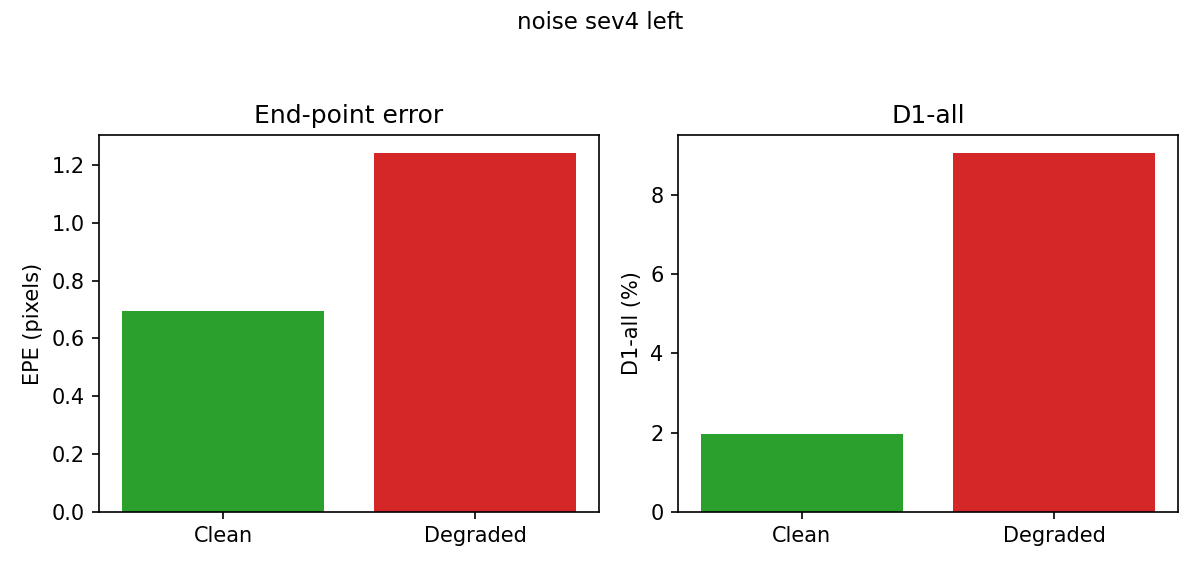

In [7]:
# ============================================
# Single Colab TEST notebook cell (all-in-one)
# - Auto-picks checkpoint path by degradation setup
# - Runs clean + degraded test
# - Saves outputs to unique run folder
# ============================================

from google.colab import drive
drive.mount('/content/drive')

import sys, subprocess, datetime
from pathlib import Path
from IPython.display import Image, display

# ------------- EDIT THESE -------------
PROJECT_DIR = Path("/content/drive/MyDrive/stereo_project")
DATA_ROOT   = "/content/drive/MyDrive/kitti_data"
PSMNET_DIR  = "/content/PSMNet"

# Test setting for this run
DEGRADE_TYPE     = "noise"   # blur | noise | occlusion
DEGRADE_SEVERITY = 4        # 1,2,3,4
DEGRADE_CAMERA   = "left"   # left | right

# If True: pick checkpoint from latest matching training run folder
AUTO_PICK_CHECKPOINT = True

# If AUTO_PICK_CHECKPOINT=False, set manually:
MANUAL_CHECKPOINT = PROJECT_DIR / "outputs" / "checkpoints" / "best.pth"

SHOW = False
# --------------------------------------

# 1) Setup
if not Path(PSMNET_DIR).exists():
    !git clone https://github.com/JiaRenChang/PSMNet.git
!pip -q install torch torchvision torchaudio numpy opencv-python pillow matplotlib

test_py = PROJECT_DIR / "test.py"
assert test_py.exists(), f"test.py not found: {test_py}"
assert Path(DATA_ROOT).exists(), f"DATA_ROOT not found: {DATA_ROOT}"
assert Path(PSMNET_DIR).exists(), f"PSMNET_DIR not found: {PSMNET_DIR}"

def auto_checkpoint(project_dir, deg_type, deg_sev, deg_cam, ckpt_name="best.pth"):
    outputs = project_dir / "outputs"
    pattern = f"type_{deg_type}_sev_{deg_sev}_cam_{deg_cam}_*"
    candidates = sorted(outputs.glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)
    if not candidates:
        raise FileNotFoundError(f"No run folders found for pattern: {pattern}")
    run_dir = candidates[0]
    ckpt = run_dir / "checkpoints" / ckpt_name
    if not ckpt.exists():
        fallback = run_dir / "checkpoints" / "last.pth"
        if fallback.exists():
            ckpt = fallback
        else:
            raise FileNotFoundError(f"No best/last checkpoint in: {run_dir / 'checkpoints'}")
    return run_dir, ckpt

if AUTO_PICK_CHECKPOINT:
    matched_run, checkpoint = auto_checkpoint(PROJECT_DIR, DEGRADE_TYPE, DEGRADE_SEVERITY, DEGRADE_CAMERA)
    print("Matched training run:", matched_run)
else:
    checkpoint = Path(MANUAL_CHECKPOINT)

assert checkpoint.exists(), f"Checkpoint not found: {checkpoint}"
print("Using checkpoint:", checkpoint)

# 2) Output folder for this test run
stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = PROJECT_DIR / "outputs" / "test_runs" / f"type_{DEGRADE_TYPE}_sev_{DEGRADE_SEVERITY}_cam_{DEGRADE_CAMERA}_{stamp}"
out_dir.mkdir(parents=True, exist_ok=True)

# 3) Run test.py
cmd = [
    sys.executable, str(test_py),
    "--data-root", str(DATA_ROOT),
    "--psmnet-dir", str(PSMNET_DIR),
    "--checkpoint", str(checkpoint),
    "--output-dir", str(out_dir),
    "--degrade-type", str(DEGRADE_TYPE),
    "--degrade-severity", str(DEGRADE_SEVERITY),
    "--degrade-camera", str(DEGRADE_CAMERA),
]
if SHOW:
    cmd.append("--show")

print("\nRunning:", " ".join(cmd))
subprocess.run(cmd, check=True)

# 4) Summary + plots (EPE / D1-all figure from test run)
print("\nDone.")
print("Output folder:", out_dir)
print("Expected files:")
print(" -", out_dir / "clean")
print(" -", out_dir / "degraded")
print(" -", out_dir / "metrics.json")
print(" -", out_dir / "epe_d1_comparison.png")

plot_path = out_dir / "epe_d1_comparison.png"
display(Image(filename=str(plot_path)))